In [1]:
import numpy as np
import os
import torch
import torchvision
from torchvision.datasets.utils import download_url
from torch.utils.data import random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data.dataloader import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import random
from tqdm import tqdm
import time
from colorama import Fore
import matplotlib.pyplot as plt

import gc

random.seed(0)
torch.manual_seed(0)

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

def save_model(model, name):
  weights_fname = f'weights/{name}.pth'
  torch.save(model.state_dict(), weights_fname)

cuda


In [3]:
prepare_imgs = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize((224, 224)), #приводим картинки к одному размеру
        torchvision.transforms.ToTensor(), # упаковывем их в тензор
        torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] # нормализуем картинки по каналам
        ),
    ]
)

dataset = ImageFolder('data/flowers', transform=prepare_imgs)

In [4]:
class ValueMeter(object):
  def __init__(self):
      self.sum = 0
      self.total = 0

  def add(self, value, n):
      self.sum += value*n
      self.total += n

  def value(self):
      return self.sum/self.total

def log(mode, epoch, loss_meter: ValueMeter, accuracy_meter, best_perf=None):
  print(
      f"[{mode}] Epoch: {epoch:0.2f}. "
      f"Loss: {loss_meter.value():.2f}. "
      f"Accuracy: {100*accuracy_meter.value():.2f}% ", end="\n")

  if best_perf:
      print(f"[best: {best_perf:0.2f}]%", end="")

In [5]:
sequential_model = nn.Sequential(
            # in: 3 x 224 x 224
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 64 x 112 x 112

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 128 x 56 x 56

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 256 x 28 x 28

            nn.Flatten(),
            nn.Linear(256*28*28, 1024), 
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 5)
)
sequential_model.to(device)


Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU()
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU()
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU()
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU()
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (15): Flatten(start_dim=1, end_dim=-1)
  (16): Linear(in_features=200704, out_features=1024, bias=True)
  (17): ReLU()
  (18): Linear(in_features=1024, out_features=512, bias=True)
  (19): ReLU()
  (20): Lin

In [6]:
optimizer = torch.optim.Adam(params = sequential_model.parameters())
lr = 0.001

In [7]:
train_set, val_set = torch.utils.data.random_split(dataset, [len(dataset)-1000, 1000])

def create_loaders() -> dict[str, DataLoader]:
  batch_size = 32

  print('Размер обучающего и валидационного датасета: ', len(train_set), len(val_set))

  loaders = {
    'training': DataLoader(
      train_set, batch_size, pin_memory=True, num_workers=4, shuffle=True
    ),
    'validation':DataLoader(
      val_set, batch_size, pin_memory=True, num_workers=4, shuffle=False
    )
  }

  return loaders
  
loaders = create_loaders()

Размер обучающего и валидационного датасета:  3317 1000


In [8]:
def calc_accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [9]:
def trainval(model, loaders, optimizer, epochs=10):
    start_time = time.time()

    loss_meter = {'training': ValueMeter(), 'validation': ValueMeter()}
    accuracy_meter = {'training': ValueMeter(), 'validation': ValueMeter()}

    loss_track = {'training': [], 'validation': []}
    accuracy_track = {'training': [], 'validation': []}

    for epoch in range(epochs): # итерации по эпохам
        for mode in ['training', 'validation']: # обучение - валидация
            # считаем градиаент только при обучении:
            with torch.set_grad_enabled(mode == 'training'):
                
                # в зависимоти от фазы переводим модель в нужный ружим:
                if mode == 'training':
                    model.train() 
                else:
                    model.eval()
                    
                for imgs, labels in tqdm(loaders[mode]):
                    imgs = imgs.to(device) # отправляем тензор на GPU
                    labels = labels.to(device)
                    bs = labels.shape[0]  # размер батча (отличается для последнего батча в лоадере)

                    preds = model(imgs) # forward pass - прогоняем тензор с картинками через модель
                    loss = F.cross_entropy(preds, labels) # считаем функцию потерь
                    acc = calc_accuracy(preds, labels) # считаем метрику

                    # храним loss и accuracy для батча
                    loss_meter[mode].add(loss.item(), bs)
                    accuracy_meter[mode].add(acc, bs)

                    # если мы в фазе обучения
                    if mode == 'training':
                        optimizer.zero_grad() # обнуляем прошлый градиент
                        loss.backward() # делаем backward pass (считаем градиент)
                        optimizer.step() # обновляем веса
            # в конце фазы выводим значения loss и accuracy
            log(mode, epoch, loss_meter[mode], accuracy_meter[mode])

            # сохраняем результаты по всем эпохам
            loss_track[mode].append(loss_meter[mode].value())
            accuracy_track[mode].append(accuracy_meter[mode].value())

    print(f'{Fore.LIGHTMAGENTA_EX}Elapsed time = {time.time() - start_time}{Fore.RESET}')
    return loss_track, accuracy_track

### Обучение базовой модели

In [10]:
first_loss_track, first_accuracy_track = trainval(sequential_model, loaders, optimizer, epochs=10)

100%|██████████| 104/104 [00:28<00:00,  3.60it/s]


[training] Epoch: 0.00. Loss: 1.41. Accuracy: 36.33% 


100%|██████████| 32/32 [00:02<00:00, 13.08it/s]


[validation] Epoch: 0.00. Loss: 1.43. Accuracy: 40.70% 


100%|██████████| 104/104 [00:28<00:00,  3.65it/s]


...

[validation] Epoch: 8.00. Loss: 1.52. Accuracy: 54.80% 


100%|██████████| 104/104 [00:28<00:00,  3.59it/s]


[training] Epoch: 9.00. Loss: 0.71. Accuracy: 71.19% 


100%|██████████| 32/32 [00:02<00:00, 13.16it/s]

[validation] Epoch: 9.00. Loss: 1.63. Accuracy: 54.98% 
Elapsed time = 310.4399814605713


In [11]:
from matplotlib import pyplot as plt

def plot_model(accuracy_track) -> None:
  plt.plot(accuracy_track['training'], label='training', color ='c')
  plt.plot(accuracy_track['validation'], label='validation', color='tomato', linestyle='--')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.grid()
  plt.legend()
  plt.show()

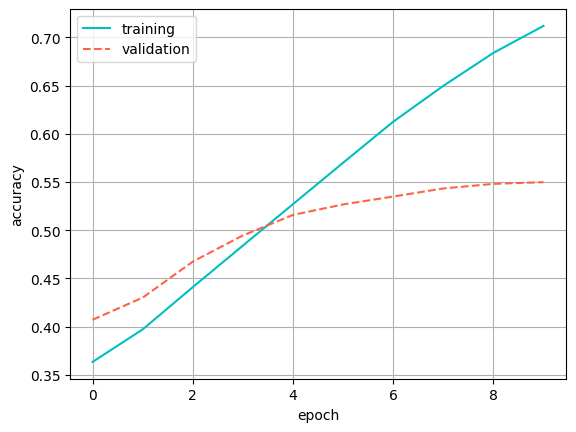

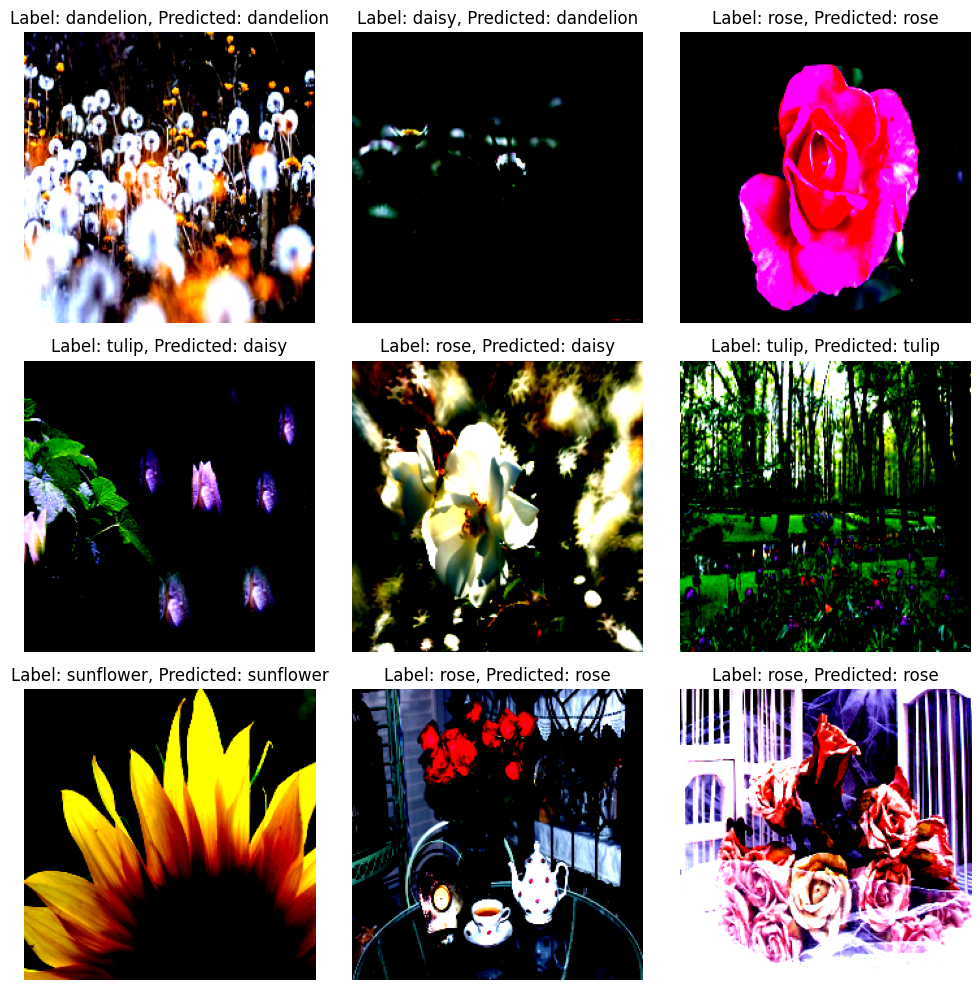

In [ ]:
def predict_image(img, model):
    # Преобразование to a batch of 1
    xb = img.unsqueeze(0).to(device)
    # Получение прогнозов от модели
    yb = model(xb)
    # Выбираем индекс с наибольшей вероятностью
    _, preds  = torch.max(yb, dim=1)
    # Получение метки класса
    return dataset.classes[preds[0].item()]


def demonstrate_predictions(model, accuracy_track):
  plot_model(accuracy_track)
  plt.figure(figsize=(10, 10))

  for i in range(1,10):
    plt.subplot(3, 3, i)
    img, label = val_set[-i]

    predicted_label = predict_image(img, model)

    plt.imshow(img.clip(0,1).permute(1, 2, 0))
    plt.axis('off')
    plt.title(f'Label: {dataset.classes[label]}, Predicted: {predicted_label}')

  plt.tight_layout()
  plt.show()
  
demonstrate_predictions(sequential_model, first_accuracy_track)

save_model(sequential_model, 'base')

Отчистка ресурсов

In [23]:
del sequential_model
gc.collect()
torch.cuda.empty_cache()

time.sleep(0.5)

### Обучение предобученной модели

In [13]:
classification_models = torchvision.models.list_models(module=torchvision.models)

print(classification_models)

sequential_model = torchvision.models.resnet50(pretrained=True)

print(sequential_model)

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'googlenet', 'inception_v3', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'squeezenet1_0

/home/danila/projects/python/aai_labs/lab3_venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/danila/projects/python/aai_labs/lab3_venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [14]:
def set_parameter_requires_grad(model):
  for param in model.parameters():
    param.requires_grad = False

set_parameter_requires_grad(sequential_model)

In [15]:
num_features = sequential_model.fc.in_features
sequential_model.fc = torch.nn.Linear(in_features=num_features, out_features=len(dataset.classes), bias=True)

In [16]:
def print_retraining_layers(model):
  for name, param in model.named_parameters():
    if param.requires_grad:
        print(f'{Fore.RED}{name}{Fore.RESET}')
    else:
        print(f'{Fore.GREEN}{name}{Fore.RESET}')
       

print_retraining_layers(sequential_model)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.0.conv3.weight
layer1.0.bn3.weight
layer1.0.bn3.bias
layer1.0.downsample.0.weight
layer1.0.downsample.1.weight
layer1.0.downsample.1.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.1.conv3.weight
layer1.1.bn3.weight
layer1.1.bn3.bias
layer1.2.conv1.weight
layer1.2.bn1.weight
layer1.2.bn1.bias
layer1.2.conv2.weight
layer1.2.bn2.weight
layer1.2.bn2.bias
layer1.2.conv3.weight
layer1.2.bn3.weight
layer1.2.bn3.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.conv3.weight
layer2.0.bn3.weight
layer2.0.bn3.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.we

Перерасчёт весов последнего слоя для ResNet50

In [17]:
random.seed(0)
torch.manual_seed(0)

sequential_model.to(device)
optimizer = torch.optim.Adam(params = sequential_model.parameters())
torch_loss_track, torch_accuracy_track = trainval(sequential_model, loaders, optimizer, epochs=10)

100%|██████████| 104/104 [00:07<00:00, 14.53it/s]


[training] Epoch: 0.00. Loss: 0.70. Accuracy: 76.06% 


100%|██████████| 32/32 [00:02<00:00, 14.47it/s]


[validation] Epoch: 0.00. Loss: 0.43. Accuracy: 85.70% 


100%|██████████| 104/104 [00:07<00:00, 14.55it/s]


...

[validation] Epoch: 8.00. Loss: 0.34. Accuracy: 88.69% 


100%|██████████| 104/104 [00:07<00:00, 14.46it/s]


[training] Epoch: 9.00. Loss: 0.34. Accuracy: 88.33% 


100%|██████████| 32/32 [00:02<00:00, 14.70it/s]

[validation] Epoch: 9.00. Loss: 0.33. Accuracy: 88.80% 
Elapsed time = 93.25810194015503


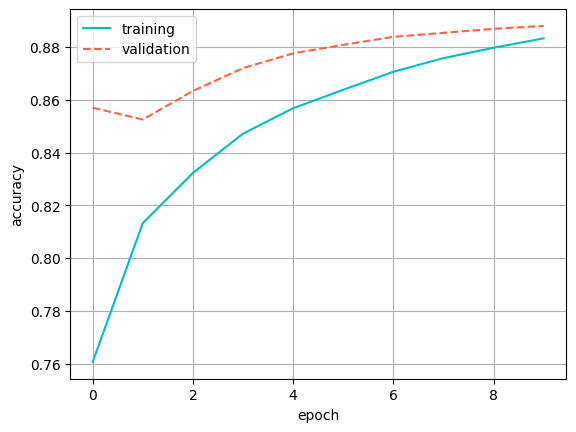

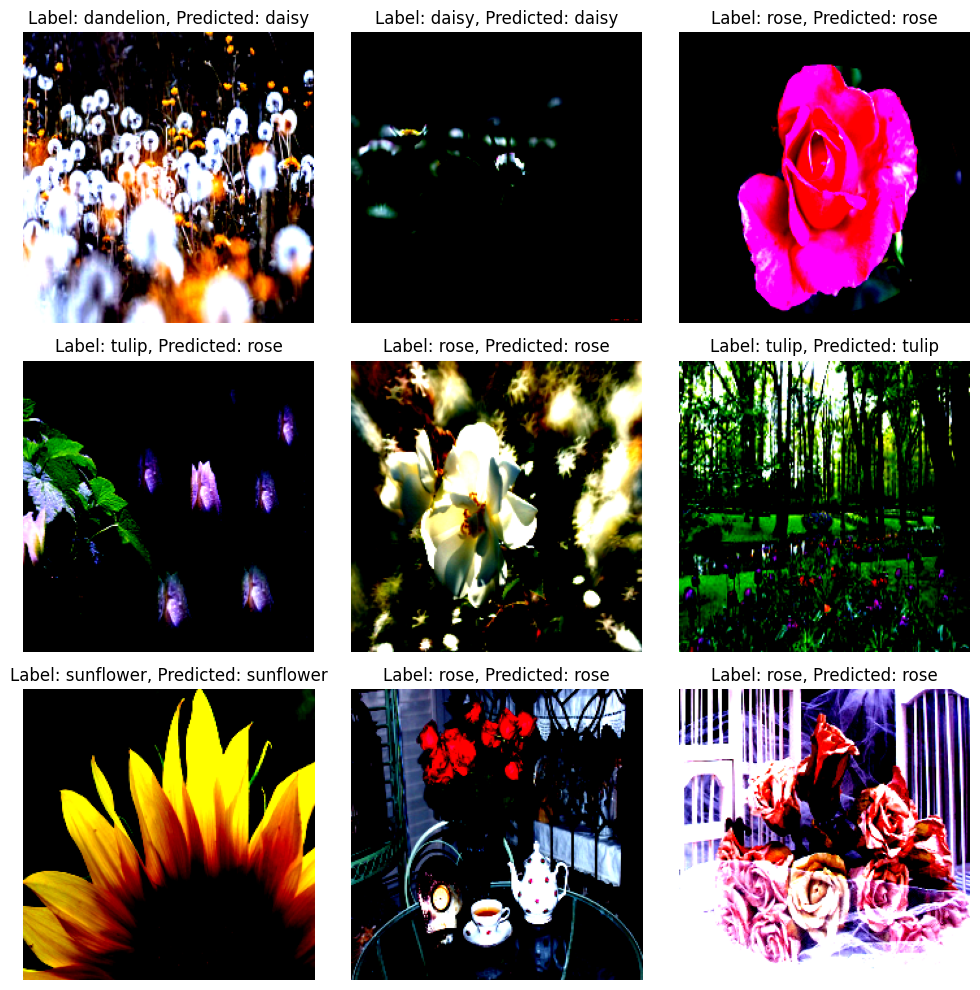

In [18]:
demonstrate_predictions(sequential_model, torch_accuracy_track)

save_model(sequential_model, "res50")

Отчитстка видеопамяти

In [19]:
del sequential_model

gc.collect()
torch.cuda.empty_cache()

time.sleep(0.5)

### Моя модель

In [20]:
sequential_model = nn.Sequential(
            # in: 3 x 224 x 224
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 16 x 112 x 112

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 32 x 56 x 56

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 64 x 28 x 28

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 128 x 14 x 14

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 256 x 7 x 7

            nn.Flatten(),
            nn.Linear(256*7*7, 2048), 
            nn.ReLU(),
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Linear(256, 5)
)

In [21]:
random.seed(0)
torch.manual_seed(0)

sequential_model.to(device)
optimizer = torch.optim.Adam(params = sequential_model.parameters())
my_loss_track, my_accuracy_track = trainval(sequential_model, loaders, optimizer, epochs=14)

100%|██████████| 104/104 [00:03<00:00, 28.07it/s]


[training] Epoch: 0.00. Loss: 1.35. Accuracy: 38.71% 


100%|██████████| 32/32 [00:00<00:00, 44.68it/s]


[validation] Epoch: 0.00. Loss: 1.22. Accuracy: 47.40% 


100%|██████████| 104/104 [00:03<00:00, 28.19it/s]


...

[validation] Epoch: 12.00. Loss: 1.26. Accuracy: 65.25% 


100%|██████████| 104/104 [00:03<00:00, 28.63it/s]


[training] Epoch: 13.00. Loss: 0.57. Accuracy: 77.37% 


100%|██████████| 32/32 [00:00<00:00, 43.24it/s]

[validation] Epoch: 13.00. Loss: 1.30. Accuracy: 65.36% 
Elapsed time = 61.812050342559814


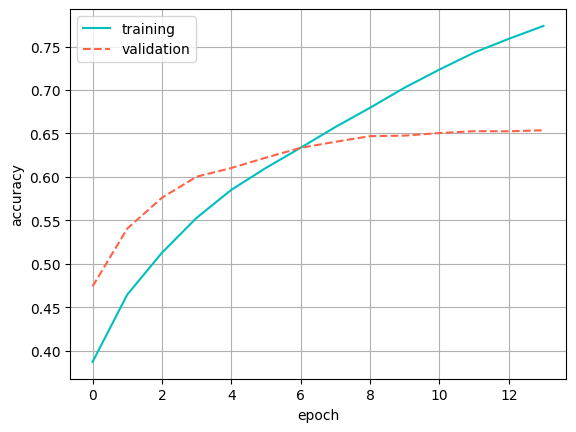

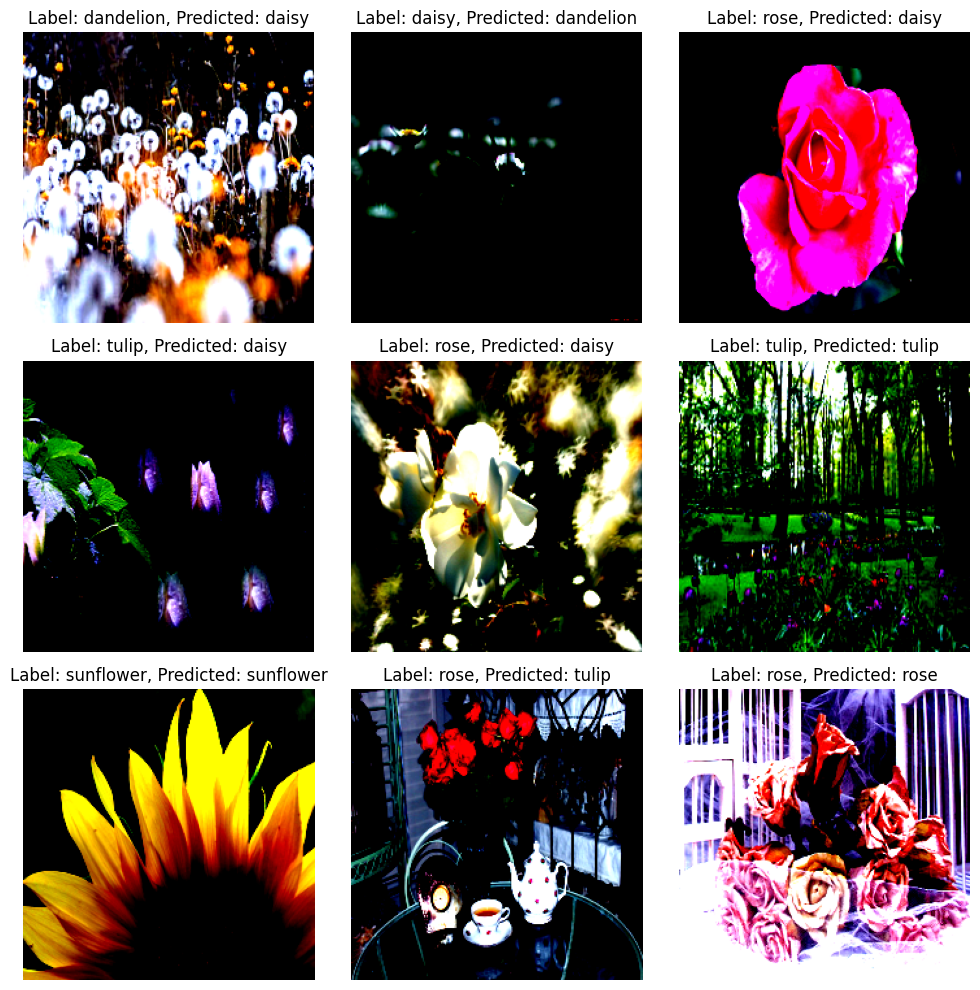

In [22]:
demonstrate_predictions(sequential_model, my_accuracy_track)

save_model(sequential_model, 'my')

### Сравнение

In [30]:
def print_final_accuracy_track(accuracy_track, model_name, color) -> None:
  print(f'{color}Final accuracy of {model_name}: {round(float(accuracy_track['validation'][-1]), 3)}{Fore.RESET}')

print_final_accuracy_track(first_accuracy_track, "Base model", Fore.CYAN)
print_final_accuracy_track(torch_accuracy_track, "ResNet", Fore.LIGHTMAGENTA_EX)
print_final_accuracy_track(my_accuracy_track, "My model", Fore.LIGHTRED_EX)

Final accuracy of Base model: 0.55
Final accuracy of ResNet: 0.888
Final accuracy of My model: 0.654


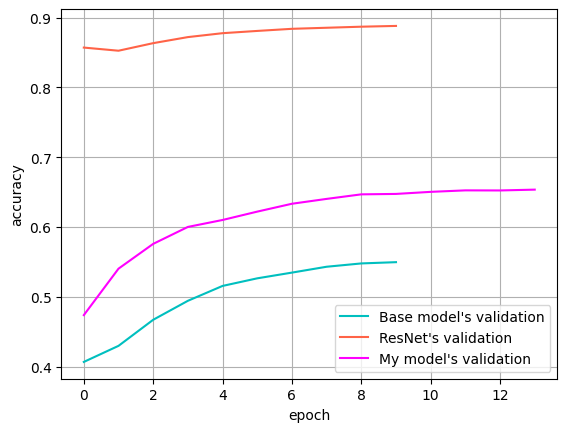

In [31]:
def plot_accuracy_track():
  plt.plot(first_accuracy_track['validation'], label="Base model's validation", color='c')
  plt.plot(torch_accuracy_track['validation'], label="ResNet's validation", color='tomato')
  plt.plot(my_accuracy_track['validation'], label="My model's validation", color='magenta')


  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.grid()
  plt.legend()
  plt.show()

plot_accuracy_track()

### Вопросы

---

#### Описание ResNet

ResNet50 — это глубокая сверточная нейронная сеть, разработанная для решения задач классификации изображений. Она является частью архитектуры ResNet (Residual Network), которая была представлена в 2015 году. ResNet50 состоит из 50 слоев.

---

#### Параметры ResNet

  - Глубина (ResNet50 -> 50 слоёв)

---

#### В чем основные отличия между сверточной нейронной сетью и "обычной" полносвязной нейронной сетью?

Каждый нейрон в полносвязной нейронной сети в одном слое связан со всеми нейронами в следующем слое. Свёрточные нейронной сети имеют локальные связи из-за фильтров. Также свёрточные нейронные сети имеют слои пулинга, которые уменьшают размерность данных и помогают извлекать наиболее значимые признаки.

---

#### Что такое transfer learning? Что такое предобучена нейронная сеть?

Transfer learning - процесс адаптации уже обученной нейронной сети под конкретные задачи. Предобученная нейронная сеть — это модель, которая была обучена на большом наборе данных для решения определенной задачи, прежде чем быть адаптированной для другой задачи.

---

#### Что такое функция для заморозки весов модели?

Функция для заморозки весов модели используется для педотвращения изменения весов слоёв предобученной нейронной сети.